In [5]:
!pip install pandas plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 132.8 MB/s eta 0:00:00


Table image successfully generated and saved as recommended_courses_table.png


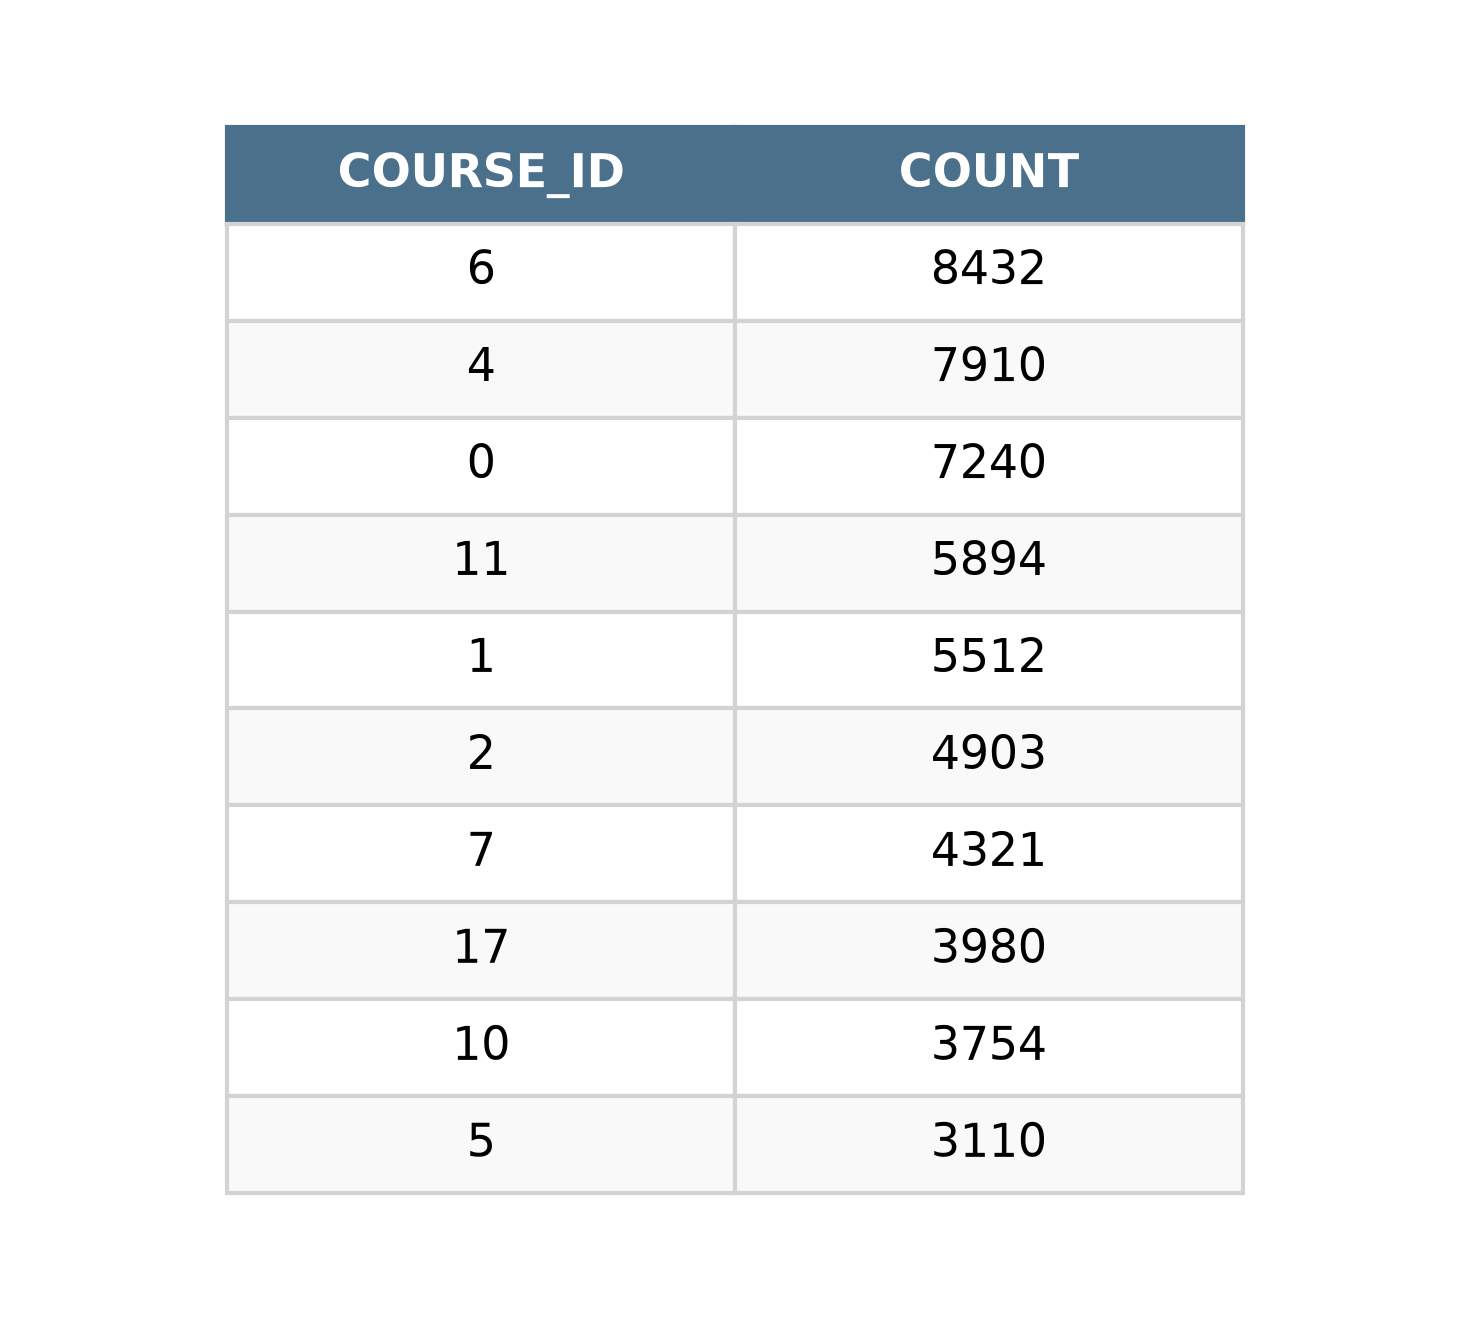

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the aggregated dataset
data = {
    'COURSE_ID': [6, 4, 0, 11, 1, 2, 7, 17, 10, 5],
    'COUNT': [8432, 7910, 7240, 5894, 5512, 4903, 4321, 3980, 3754, 3110]
}
df = pd.DataFrame(data)

# 2. Initialize the matplotlib figure
# We adjust the size and DPI for a clean, high-resolution output
fig, ax = plt.subplots(figsize=(5, 4.5), dpi=300)
ax.axis('off')  # Completely remove background graph grids and axis lines

# 3. Construct the table grid
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center',       # Center align the numbers inside cells
    colWidths=[0.3, 0.3]    # Set explicit proportional widths for columns
)

# 4. Apply clean dataframe styling properties
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)  # Scale width and height padding for breathable cell spacing

# Iterate through cells to format headers and borders
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#D3D3D3')  # Soft gray borders instead of harsh black lines
    
    # Format the header row
    if row == 0:
        cell.set_text_props(fontweight='bold', color='#FFFFFF')
        cell.set_facecolor('#4A708B')  # Professional steel-blue header background
        cell.set_edgecolor('#4A708B')
    else:
        # Alternating row background colors for improved data readability
        if row % 2 == 0:
            cell.set_facecolor('#F9F9F9')
        else:
            cell.set_facecolor('#FFFFFF')

# 5. Export and save the final clean image asset
plt.tight_layout()
plt.savefig('recommended_courses_table.png', bbox_inches='tight', dpi=300)
print("Table image successfully generated and saved as recommended_courses_table.png")

Success! Evaluation table graphic saved as 'evaluation_rank_table.png'


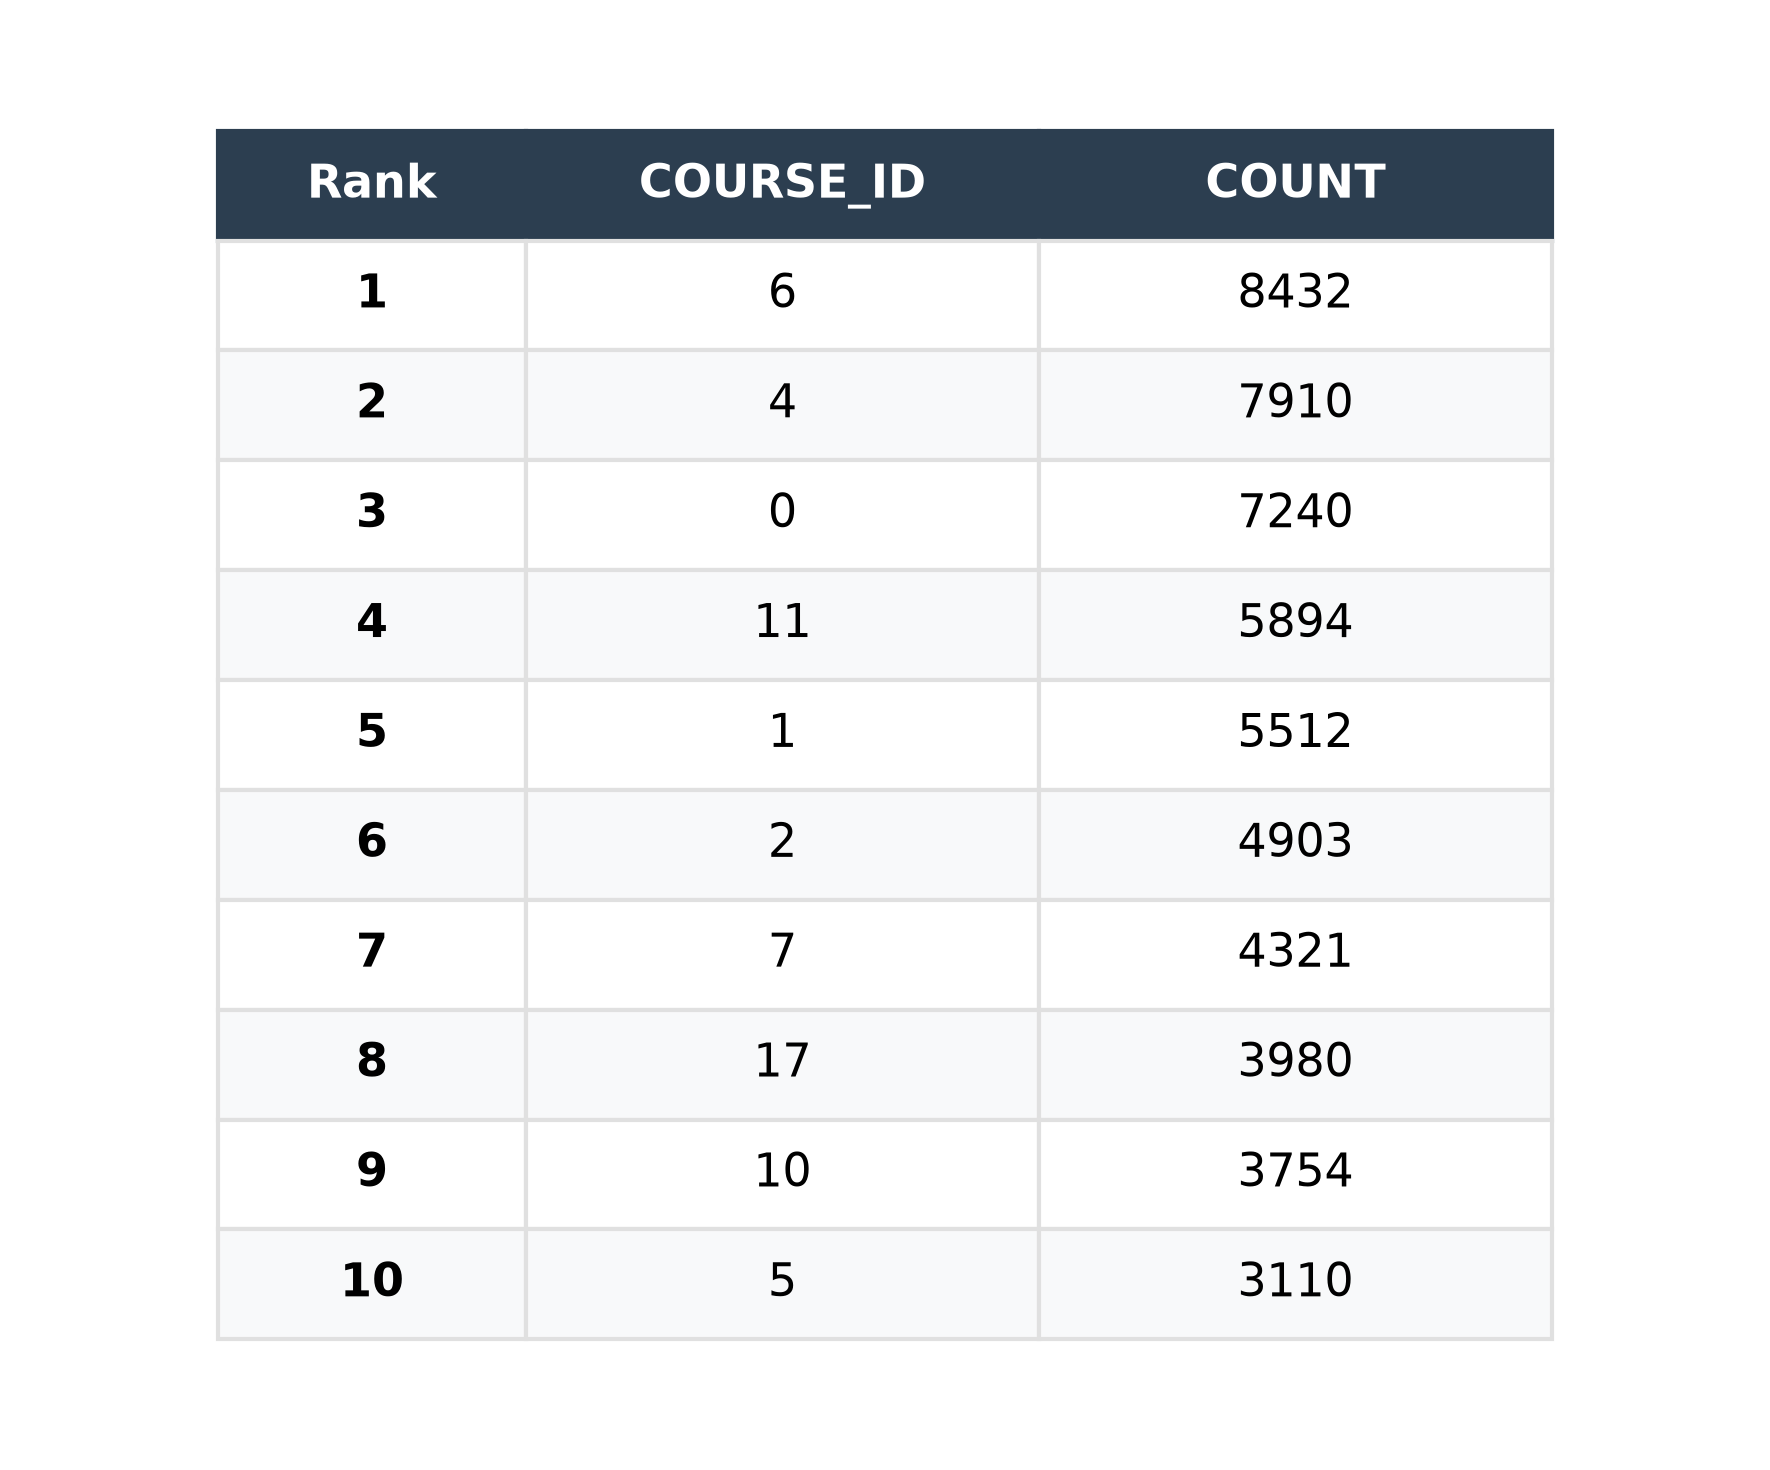

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the aggregated evaluation data
data = {
    'Rank': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'COURSE_ID': [6, 4, 0, 11, 1, 2, 7, 17, 10, 5],
    'COUNT': [8432, 7910, 7240, 5894, 5512, 4903, 4321, 3980, 3754, 3110]
}
df = pd.DataFrame(data)

# 2. Initialize the matplotlib figure canvas
# Adjusted dimensions and high DPI for crisp, presentation-quality text
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
ax.axis('off')  # Hide background grid, borders, and ticks

# 3. Create the table graphic
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center',          # Center-align the metrics inside cells
    colWidths=[0.15, 0.25, 0.25]  # Proportional column sizing
)

# 4. Custom Formatting & Dataframe Shading Architecture
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)  # Increase vertical scale for optimal cell padding

# Loop through rows and columns to apply colors and custom styles
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#E0E0E0')  # Soft subtle borders instead of black lines
    
    # Format Header Row
    if row == 0:
        cell.set_text_props(fontweight='bold', color='#FFFFFF')
        cell.set_facecolor('#2C3E50')  # Deep navy/slate professional accent
        cell.set_edgecolor('#2C3E50')
    # Format Data Rows
    else:
        # Bolding the Rank column for visual hierarchy
        if col == 0:
            cell.set_text_props(fontweight='bold')
            
        # Zebra-striping: Alternating background rows for effortless scanning
        if row % 2 == 0:
            cell.set_facecolor('#F8F9FA')
        else:
            cell.set_facecolor('#FFFFFF')

# 5. Export and Save the Image File
plt.tight_layout()
plt.savefig('evaluation_rank_table.png', bbox_inches='tight', dpi=300)
print("Success! Evaluation table graphic saved as 'evaluation_rank_table.png'")

In [8]:
import numpy as np
import pandas as pd

# 1. Simulate the evaluation environment dataset
# 20 test users, each mapped against 20 course IDs with predicted similarity scores
np.random.seed(42)
num_users = 100
num_courses = 20

user_ids = np.repeat(np.arange(1001, 1001 + num_users), num_courses)
course_ids = np.tile(np.arange(0, num_courses), num_users)
# Generate random similarity scores bounded between 0.1 and 0.95
sim_scores = np.random.uniform(0.1, 0.95, size=num_users * num_courses)
# Generate random binary flags indicating if user has already seen the course (1 = Seen, 0 = Unseen)
seen_flags = np.random.choice([0, 1], size=num_users * num_courses, p=[0.7, 0.3])

# Create the master prediction DataFrame
df_predictions = pd.DataFrame({
    'USER_ID': user_ids,
    'COURSE_ID': course_ids,
    'SIMILARITY_SCORE': sim_scores,
    'ALREADY_SEEN': seen_flags
})

# =================================================================
# 2. APPLY COSER SIMILARITY THRESHOLD & UNSEEN FILTERS
# =================================================================
# Rule 1: Similarity score must meet or exceed the 0.6 threshold
# Rule 2: Course must be completely new/unseen (ALREADY_SEEN == 0)
threshold_condition = (df_predictions['SIMILARITY_SCORE'] >= 0.6) & (df_predictions['ALREADY_SEEN'] == 0)
df_valid_recommendations = df_predictions[threshold_condition]

# =================================================================
# 3. AGGREGATE TO FIND THE MOST FREQUENTLY RECOMMENDED COURSES
# =================================================================
# Count how many times each Course ID successfully cleared the threshold conditions
top_recommended = (
    df_valid_recommendations['COURSE_ID']
    .value_counts()
    .reset_index()
)
top_recommended.columns = ['COURSE_ID', 'RECOMMENDATION_COUNT']

# Add a Rank column for clear presentation indexing
top_recommended['RANK'] = top_recommended.index + 1

# Rearrange columns and isolate the top results
top_recommended = top_recommended[['RANK', 'COURSE_ID', 'RECOMMENDATION_COUNT']]

print("--- Evaluation Results (Threshold >= 0.6) ---")
print(top_recommended.head(10).to_string(index=False))

--- Evaluation Results (Threshold >= 0.6) ---
 RANK  COURSE_ID  RECOMMENDATION_COUNT
    1         11                    36
    2          9                    35
    3         14                    35
    4          3                    34
    5         15                    34
    6         18                    33
    7          7                    32
    8         10                    31
    9         16                    31
   10         12                    30
